<a href="https://colab.research.google.com/github/2022311057/Graduation_research/blob/main/MeCab_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt install mecab libmecab-dev mecab-ipadic-utf8 git make curl xz-utils file -y

!apt-get install -y nkf

!apt-get install -y uconv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
make is already the newest version (4.3-4.1build1).
make set to manually installed.
xz-utils is already the newest version (5.2.5-2ubuntu1).
xz-utils set to manually installed.
curl is already the newest version (7.81.0-1ubuntu1.21).
file is already the newest version (1:5.41-3ubuntu0.1).
git is already the newest version (1:2.34.1-1ubuntu1.15).
The following additional packages will be installed:
  libmecab2 mecab-ipadic mecab-utils
The following NEW packages will be installed:
  libmecab-dev libmecab2 mecab mecab-ipadic mecab-ipadic-utf8 mecab-utils
0 upgraded, 6 newly installed, 0 to remove and 2 not upgraded.
Need to get 7,367 kB of archives.
After this operation, 59.3 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libmecab2 amd64 0.996-14build9 [199 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libmecab-dev amd64 0.996-14

In [ ]:
# 既存の古いMeCab関連があれば削除し、新しいものをインストールする
!pip install --upgrade mecab-python3 unidic-lite jaconv

!pip install sentence-transformers scikit-learn

#!pip install music21

!pip install pulp fugashi pykakasi japanize_matplotlib


!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 30.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 42.4 MB/s eta 0:00:00
  Created wheel for unidic-lite: filename=unidic_lite-1.0.8-py3-none-any.whl size=47658817 sha256=1b08b648ad7125fb83a71b15d0a74083a2eaebede6eaea12543edbbfaa0e8af2
  Stored in directory: /root/.cache/pip/wheels/5e/1f/0f/4d43887e5476d956fae828ee9b6687becd5544d68b51ed633d
Successfully built unidic-lite
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 44.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.0 MB/s eta 0:00:00
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=451986346794d5bab344b0f0aea8099b9429371d459bdd5cd433fd8ac37b4749
  Stored in directory: /root/.cache/pip/

In [ ]:
import MeCab

t = MeCab.Tagger('-O wakati')
result = t.parse('私は大学生です。')
print(result.split())

['私', 'は', '大学', '生', 'です', '。']


In [ ]:
import MeCab
import subprocess

# MeCabで形態素解析して「読み（カタカナ）」を取得
def get_katakana_reading(sentence):
    tagger = MeCab.Tagger()
    node = tagger.parseToNode(sentence)
    readings = []

    while node:
        features = node.feature.split(',')
        if len(features) > 8 and features[8] != '*':
            readings.append(features[8])
        node = node.next

    return ''.join(readings)

# uconvでローマ字（ヘボン式）に変換
def katakana_to_romaji_with_uconv_hepburn(text):
    result = subprocess.run(
        ['uconv', '-f', 'utf-8', '-t', 'utf-8', '-x', 'Katakana-Latin'],
        input=text.encode('utf-8'),
        stdout=subprocess.PIPE
    )
    return result.stdout.decode('utf-8').strip()

# ヘボン式を訓令式に変換
def hepburn_to_kunrei(text):
    replacements = {
        'shi': 'si',
        'chi': 'ti',
        'tsu': 'tu',
        'fu': 'hu',
        'ji': 'zi',
        'ja': 'zya',
        'ju': 'zyu',
        'jo': 'zyo',
        'sha': 'sya',
        'shu': 'syu',
        'sho': 'syo',
        'cha': 'tya',
        'chu': 'tyu',
        'cho': 'tyo',
        'hya': 'hya',
        'hyu': 'hyu',
        'hyo': 'hyo',
        'mya': 'mya',
        'myu': 'myu',
        'myo': 'myo',
        'rya': 'rya',
        'ryu': 'ryu',
        'ryo': 'ryo',
        'n': 'n',
        'aa': 'â', 'ii': 'î', 'uu': 'û', 'ee': 'ê', 'oo': 'ô',
    }
    result = text
    for before, after in replacements.items():
        result = result.replace(before, after)
    return result

# 母音列を抽出（nも母音扱い！）
def extract_vowels_with_n(romaji_text):
    vowels = 'aeioun'  # ここでnも入れる
    return ''.join([c for c in romaji_text.lower() if c in vowels])

# レーベンシュタイン距離を計算
def levenshtein_distance(s1, s2):
    len_s1 = len(s1)
    len_s2 = len(s2)

    dp = [[0] * (len_s2 + 1) for _ in range(len_s1 + 1)]

    for i in range(len_s1 + 1):
        dp[i][0] = i
    for j in range(len_s2 + 1):
        dp[0][j] = j

    for i in range(1, len_s1 + 1):
        for j in range(1, len_s2 + 1):
            if s1[i-1] == s2[j-1]:
                cost = 0
            else:
                cost = 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )
    return dp[len_s1][len_s2]

# センテンスをローマ字母音列に変換
def sentence_to_vowels(sentence):
    katakana = get_katakana_reading(sentence)
    romaji_hepburn = katakana_to_romaji_with_uconv_hepburn(katakana)
    romaji_kunrei = hepburn_to_kunrei(romaji_hepburn)
    vowels = extract_vowels_with_n(romaji_kunrei)
    return vowels

# --- ここから使う例 ---

sentence = "りんご"
sub_sentence1 = "インコ"
sub_sentence2 = "シカゴ"

vowels_sentence = sentence_to_vowels(sentence)
vowels_sub1 = sentence_to_vowels(sub_sentence1)
vowels_sub2 = sentence_to_vowels(sub_sentence2)

print(f"母音列 (元文): {vowels_sentence}")
print(f"母音列 (sub1): {vowels_sub1}")
print(f"母音列 (sub2): {vowels_sub2}")

dist1 = levenshtein_distance(vowels_sentence, vowels_sub1)
dist2 = levenshtein_distance(vowels_sentence, vowels_sub2)

print(f"距離（{sentence} vs {sub_sentence1}）: {dist1}")
print(f"距離（{sentence} vs {sub_sentence2}）: {dist2}")


母音列 (元文): 
母音列 (sub1): ino
母音列 (sub2): iao
距離（りんご vs インコ）: 3
距離（りんご vs シカゴ）: 3


In [ ]:
# @title
import MeCab
import subprocess
import itertools
import re

# ------------------------------
# 1. 変換関連の処理
# ------------------------------
def get_katakana_reading(sentence):
    tagger = MeCab.Tagger()
    node = tagger.parseToNode(sentence)
    readings = []
    while node:
        features = node.feature.split(',')
        if len(features) > 8 and features[8] != '*':
            readings.append(features[8])
        node = node.next
    return ''.join(readings)

def katakana_to_romaji_with_uconv_hepburn(text):
    result = subprocess.run(
        ['uconv', '-f', 'utf-8', '-t', 'utf-8', '-x', 'Katakana-Latin'],
        input=text.encode('utf-8'),
        stdout=subprocess.PIPE
    )
    return result.stdout.decode('utf-8').strip()

def hepburn_to_kunrei_with_nn(text):
    result = text.lower()
    replacements = {
        'shi': 'si', 'chi': 'ti', 'tsu': 'tu', 'fu': 'hu', 'ji': 'zi',
        'ja': 'zya', 'ju': 'zyu', 'jo': 'zyo',
        'sha': 'sya', 'shu': 'syu', 'sho': 'syo',
        'cha': 'tya', 'chu': 'tyu', 'cho': 'tyo',
        'â': 'aa', 'î': 'ii', 'û': 'uu', 'ê': 'ee', 'ô': 'oo',
        'ā': 'aa', 'ī': 'ii', 'ū': 'uu', 'ē': 'ee', 'ō': 'oo',
    }
    for before, after in replacements.items():
        result = result.replace(before, after)

    result = re.sub(r'n(?![aeiou])', 'nn', result)
    result = re.sub(r'n$', 'nn', result)
    result = re.sub(r'\bna', 'a', result)
    result = re.sub(r'\bni', 'i', result)
    result = re.sub(r'\bnu', 'u', result)
    result = re.sub(r'\bne', 'e', result)
    result = re.sub(r'\bno', 'o', result)

    return result

def extract_vowels(text):
    text = text.replace('nn', 'N')
    return ''.join([c for c in text if c in 'aeiouN'])

def sentence_to_vowels(sentence):
    katakana = get_katakana_reading(sentence)
    romaji_hepburn = katakana_to_romaji_with_uconv_hepburn(katakana)
    romaji_kunrei = hepburn_to_kunrei_with_nn(romaji_hepburn)
    vowels = extract_vowels(romaji_kunrei)
    return vowels

# ------------------------------
# 2. グループ分け
# ------------------------------
def group_by_head_and_tail_vowels(words_with_vowels):
    groups = {}
    for word, vowels in words_with_vowels:
        if not vowels:
            continue
        head = vowels[0]
        tail = vowels[-1]
        key = (head, tail)
        if key not in groups:
            groups[key] = []
        groups[key].append((word, vowels))
    return groups

# ------------------------------
# 3. ペア評価（韻密度 & 連続性）
# ------------------------------
def calc_rhyme_density(v1, v2):
    match_count = sum(1 for a, b in zip(v1, v2) if a == b)
    density = match_count / len(v1)
    return match_count, density

def calc_longest_consecutive_match(v1, v2):
    max_len = 0
    current_len = 0
    for a, b in zip(v1, v2):
        if a == b:
            current_len += 1
            max_len = max(max_len, current_len)
        else:
            current_len = 0
    return max_len

def score_pair(w1, w2, v1, v2):
    match_count, density = calc_rhyme_density(v1, v2)
    consecutive = calc_longest_consecutive_match(v1, v2)
    score = density * 5 + consecutive  # ★ 密度を強めに重み付け
    return {
        'pair': (w1, w2),
        'vowels': (v1, v2),
        'density': density,
        'consecutive': consecutive,
        'score': score
    }

def score_group_pairs(group):
    scored = []
    for (w1, v1), (w2, v2) in itertools.combinations(group, 2):
        if len(v1) == len(v2):
            result = score_pair(w1, w2, v1, v2)
            scored.append(result)
    return scored

def process_all_groups(groups):
    all_results = []
    for group_key, group in groups.items():
        results = score_group_pairs(group)
        all_results.extend(results)
    return sorted(all_results, key=lambda x: -x['score'])

# ------------------------------
# 4. 結果表示
# ------------------------------
def show_all_pairs(pairs):
    for i, pair in enumerate(pairs, 1):
        w1, w2 = pair['pair']
        v1, v2 = pair['vowels']
        print(f"第{i}位: '{w1}' <-> '{w2}'")
        print(f"  母音列: {v1} <-> {v2}")
        print(f"  韻の密度: {pair['density']:.2f}")
        print(f"  韻の連続性: {pair['consecutive']}")
        print(f"  スコア: {pair['score']:.2f}")
        print()

# ------------------------------
# 5. メイン処理
# ------------------------------
if __name__ == '__main__':
    # 入力ファイル
    with open("words.txt", encoding='utf-8') as f:
        words = [line.strip() for line in f if line.strip()]

    # 母音抽出
    words_with_vowels = [(word, sentence_to_vowels(word)) for word in words]

    # 頭韻・脚韻でグループ化
    grouped = group_by_head_and_tail_vowels(words_with_vowels)

    # スコア付きでペア生成
    scored_pairs = process_all_groups(grouped)

    # 結果表示（全件）
    show_all_pairs(scored_pairs)

import random

def build_groups_from_top_pairs(scored_pairs, grouped, max_groups=8):
    used_words = set()
    groups = []

    for pair_info in scored_pairs:
        w1, w2 = pair_info['pair']
        if w1 in used_words or w2 in used_words:
            continue

        group = {w1, w2}
        candidates = find_candidates_for_pair((w1, w2), scored_pairs, used_words)

        for candidate in candidates:
            if len(group) >= 4:
                break
            group.add(candidate)

        # 足りなければランダム補完
        if len(group) < 4:
            head = pair_info['vowels'][0][0]
            tail = pair_info['vowels'][0][-1]
            group = fill_group_randomly_if_needed(group, grouped, head, tail, used_words)

        if len(group) == 4:
            groups.append(list(group))
            used_words.update(group)

        if len(groups) >= max_groups:
            break

    return groups

def find_candidates_for_pair(pair, scored_pairs, used_words):
    w1, w2 = pair
    candidates = {}

    for item in scored_pairs:
        x, y = item['pair']
        if x in used_words or y in used_words:
            continue

        if x == w1 and y not in used_words:
            candidates[y] = candidates.get(y, 0) + item['score']
        elif y == w1 and x not in used_words:
            candidates[x] = candidates.get(x, 0) + item['score']
        elif x == w2 and y not in used_words:
            candidates[y] = candidates.get(y, 0) + item['score']
        elif y == w2 and x not in used_words:
            candidates[x] = candidates.get(x, 0) + item['score']

    # スコア順で候補を返す
    return [word for word, _ in sorted(candidates.items(), key=lambda x: -x[1])]

def fill_group_randomly_if_needed(group, grouped, head, tail, used_words):
    key = (head, tail)
    if key not in grouped:
        return group

    candidates = [w for (w, _) in grouped[key] if w not in group and w not in used_words]
    random.shuffle(candidates)
    while len(group) < 4 and candidates:
        group.add(candidates.pop())
    return group

# ------------------------------
# メイン処理に追加
# ------------------------------
if __name__ == '__main__':
    with open("words.txt", encoding='utf-8') as f:
        words = [line.strip() for line in f if line.strip()]

    words_with_vowels = [(word, sentence_to_vowels(word)) for word in words]
    grouped = group_by_head_and_tail_vowels(words_with_vowels)
    scored_pairs = process_all_groups(grouped)

    # 結果表示：全ペア一覧（必要に応じてコメントアウト）
    # show_all_pairs(scored_pairs)

    # 上位ペアから8グループ作成
    final_groups = build_groups_from_top_pairs(scored_pairs, grouped, max_groups=8)

    print("=== 最終グループ ===")
    for i, group in enumerate(final_groups, 1):
        print(f"グループ{i}: {', '.join(group)}")


FileNotFoundError: [Errno 2] No such file or directory: 'words.txt'

In [ ]:
# @title
import MeCab
import re
from pykakasi import kakasi
import itertools

# pykakasi 初期化（訓令式ローマ字）
kks = kakasi()
kks.setMode("J", "K")
kks.setMode("H", "a")
kks.setMode("K", "a")
kks.setMode("r", "Kunrei")
conv = kks.getConverter()

# カタカナ読み取得（MeCab）
def get_katakana_reading(sentence):
    tagger = MeCab.Tagger()
    node = tagger.parseToNode(sentence)
    readings = []
    while node:
        features = node.feature.split(',')
        if len(features) > 8 and features[8] != '*':
            readings.append(features[8])
        node = node.next
    return ''.join(readings)

# ローマ字＆母音列取得（nn→N含む）
def sentence_to_vowels_verbose(sentence):
    katakana = get_katakana_reading(sentence)
    romaji = conv.do(katakana).lower()
    romaji = re.sub(r'n(?![aeiou])', 'nn', romaji)
    romaji = re.sub(r'n$', 'nn', romaji)

    vowel_seq = []
    i = 0
    while i < len(romaji):
        if romaji[i:i+2] == 'nn':
            vowel_seq.append('N')
            i += 2
            while i < len(romaji) and romaji[i:i+2] == 'nn':
                i += 2
        elif romaji[i] in 'aeiou':
            vowel_seq.append(romaji[i])
            i += 1
        else:
            i += 1

    vowels = ''.join(vowel_seq)
    return romaji, vowels

# 単語読み込み
with open("words.txt", encoding="utf-8") as f:
    all_words = list(set([line.strip() for line in f if line.strip()]))

print("=== Step 1: 母音抽出とフィルタ ===")
vowel_dict = {}
for w in all_words:
    romaji, vowels = sentence_to_vowels_verbose(w)
    if vowels:
        print(f"[OK] {w} → romaji: {romaji} → vowel: {vowels}")
        vowel_dict[w] = vowels
    else:
        print(f"[WARN] {w} → romaji: {romaji} → vowel: ''")

words = list(vowel_dict.keys())
print(f"\n使用可能な単語数: {len(words)}")

# 韻スコア計算
print("\n=== Step 2: 韻スコア計算 ===")
rhyme_scores = {}
rhyme_breakdowns = {}
for w1, w2 in itertools.combinations(words, 2):
    v1 = vowel_dict[w1]
    v2 = vowel_dict[w2]
    if len(v1) == 0 or len(v2) == 0 or len(v1) != len(v2):
        continue

    score_breakdown = {}
    if v1[0] == v2[0]:
        score_breakdown['head_match'] = 2
    if v1[-1] == v2[-1]:
        score_breakdown['tail_match'] = 10
    match_count = sum(a == b for a, b in zip(v1, v2))
    density = match_count / len(v1)
    max_streak = 0
    streak = 0
    for a, b in zip(v1, v2):
        if a == b:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0

    score_breakdown['rhyme_density'] = round(density * 5, 2)
    score_breakdown['rhyme_streak'] = max_streak

    total_score = sum(score_breakdown.values())
    if total_score >= 3.0:
        rhyme_scores[(w1, w2)] = total_score
        rhyme_breakdowns[(w1, w2)] = score_breakdown

print(f"計算された有効なペア数: {len(rhyme_scores)}")

# 構造ペア定義（行方向・列方向）
print("\n=== Step 3: 構造ペアの定義 ===")
rows, cols = 8, 4
positions = [(i, j) for i in range(rows) for j in range(cols)]
structure_pairs = []

for k in range(0, 8, 2):
    structure_pairs += [
        ((k, 0), (k+1, 0)), ((k, 1), (k+1, 1)),
        ((k, 2), (k+1, 2)), ((k, 3), (k+1, 3))
    ]

print(f"構造ペア数: {len(structure_pairs)}")

# グリーディ配置戦略
print("\n=== Step 4: グリーディに単語を配置 ===")
used_words = set()
selected_pairs = []
grid = [['' for _ in range(cols)] for _ in range(rows)]

for (p1, p2) in structure_pairs:
    best_score = -1
    best_pair = None
    for (w1, w2), score in rhyme_scores.items():
        if w1 in used_words or w2 in used_words:
            continue
        if score > best_score:
            best_score = score
            best_pair = (w1, w2)
    if best_pair:
        w1, w2 = best_pair
        used_words.update([w1, w2])
        grid[p1[0]][p1[1]] = w1
        grid[p2[0]][p2[1]] = w2
        selected_pairs.append(((w1, p1), (w2, p2), best_score, rhyme_breakdowns[(w1, w2)]))

print("\n=== Step 5: グリッド表示 ===")
for i, row in enumerate(grid):
    print(f"{i+1}行目: " + " | ".join(w or '（空）' for w in row))

print("\n=== Step 6: 採用されたペア一覧（位置とスコア） ===")
for (w1, p1), (w2, p2), score, breakdown in selected_pairs:
    print(f"{w1}（{p1}） × {w2}（{p2}） → score: {score}, breakdown: {breakdown}")


In [ ]:
# @title
# -*- coding: utf-8 -*-
import pulp
import math
from collections import defaultdict

def evaluate_grid(model, x, z, rhyme_scores, rhyme_details, words, positions, structure_pairs):
    print("\n=== 自動評価スクリプト開始 ===")

    ##########################
    # 1. Rhyme Density (Malmi et al., 2015)
    ##########################
    densities = [
        bd['rhyme_density']
        for (w1, w2, _, bd) in rhyme_details
        for (p1, p2) in structure_pairs
        if pulp.value(z[w1, w2, p1, p2]) == 1
    ]
    avg_density = sum(densities) / len(densities) if densities else 0.0
    print(f"[Rhyme Density] 平均韻密度（Malmi+2015）: {avg_density:.3f}")

    ##########################
    # 2. Max Rhyme Streak (Fernandez et al., 2018)
    ##########################
    streaks = [
        bd['rhyme_streak']
        for (w1, w2, _, bd) in rhyme_details
        for (p1, p2) in structure_pairs
        if pulp.value(z[w1, w2, p1, p2]) == 1
    ]
    max_streak = max(streaks) if streaks else 0
    print(f"[Rhyme Streak] 最大韻の連続長（Fernandez+2018）: {max_streak}")

    ##########################
    # 3. Rhyme Pair Coverage (Potash et al., 2018)
    ##########################
    used_pairs = sum([
        1 for (w1, w2) in rhyme_scores
        for (p1, p2) in structure_pairs
        if pulp.value(z[w1, w2, p1, p2]) == 1
    ])
    coverage = used_pairs / len(structure_pairs) if structure_pairs else 0.0
    print(f"[Rhyme Coverage] 使用された韻ペア率（Potash+2018）: {coverage:.3f}（{used_pairs} / {len(structure_pairs)}）")

    ##########################
    # 4. Lexical Diversity (Potash et al., 2018)
    ##########################
    unique_words = set()
    for w in words:
        for p in positions:
            if pulp.value(x[w][p]) == 1:
                unique_words.add(w)
    ttr = len(unique_words) / len(positions)
    print(f"[Lexical Diversity] Type-Token Ratio（語彙多様性）（Potash+2018）: {ttr:.3f}")

    ##########################
    # 5. Structural Compactness (Inspired by Malmi et al., 2015)
    ##########################
    penalty_sum = 0
    for (w1, w2) in rhyme_scores:
        for (p1, p2) in structure_pairs:
            if pulp.value(z[w1, w2, p1, p2]) == 1:
                dist = abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])
                penalty_sum += dist
    avg_distance = penalty_sum / used_pairs if used_pairs > 0 else 0.0
    print(f"[Compactness] 平均配置距離（Malmi+2015 のコスト項参考）: {avg_distance:.3f}")

    ##########################
    # 6. Visual Symmetry (オリジナル+詩的構造に基づく)
    ##########################
    symmetry_score = 0
    symmetry_count = 0
    for (w1, w2) in rhyme_scores:
        for (p1, p2) in structure_pairs:
            if pulp.value(z[w1, w2, p1, p2]) == 1:
                if p1[0] == p2[0] and abs(p1[1] - p2[1]) == 2:
                    symmetry_score += 1  # 横の交差韻
                elif p1[1] == p2[1] and abs(p1[0] - p2[0]) == 1:
                    symmetry_score += 1  # 縦の並列韻
                symmetry_count += 1
    symmetry_ratio = symmetry_score / symmetry_count if symmetry_count else 0
    print(f"[Visual Symmetry] 韻の視覚的対称性比率: {symmetry_ratio:.3f}")

    ##########################
    # 総合評価（仮の平均スコア）
    ##########################
    composite_score = (
        avg_density * 0.3 +
        max_streak * 0.1 +
        coverage * 0.2 +
        ttr * 0.2 +
        (1.0 - avg_distance / 10.0) * 0.1 +  # 正規化した距離
        symmetry_ratio * 0.1
    )
    print(f"\n✅ [総合スコア（正規化平均）]: {composite_score:.3f}")

    return {
        "avg_density": avg_density,
        "max_streak": max_streak,
        "coverage": coverage,
        "ttr": ttr,
        "avg_distance": avg_distance,
        "symmetry_ratio": symmetry_ratio,
        "composite_score": composite_score
    }


In [ ]:
# @title
# -*- coding: utf-8 -*-
import re
import pulp
import itertools
import random
from pykakasi import kakasi
import matplotlib.pyplot as plt
import networkx as nx

# ==========================================
# 読み仮名取得ロジック (pykakasi修正版)
# ==========================================
# pykakasi を「すべてカタカナに変換」するように設定
kks = kakasi()
kks.setMode("J", "K")  # Kanji(漢字)   → Katakana
kks.setMode("H", "K")  # Hiragana(ひらがな) → Katakana (※ここが重要)
kks.setMode("K", "K")  # Katakana      → Katakana
conv = kks.getConverter()

def get_katakana_reading(text):
    """
    漢字・ひらがな混じりのテキストをカタカナに変換する
    例: 夕涼み → ユウスズミ
    """
    return conv.do(text)

def katakana_to_vowels_direct(katakana):
    """
    カタカナ文字列を受け取り、母音列(a,i,u,e,o,N)に変換する
    """
    # 母音マッピング
    vowel_map = {
        'ア':'a', 'カ':'a', 'サ':'a', 'タ':'a', 'ナ':'a', 'ハ':'a', 'マ':'a', 'ヤ':'a', 'ラ':'a', 'ワ':'a', 'ガ':'a', 'ザ':'a', 'ダ':'a', 'バ':'a', 'パ':'a',
        'イ':'i', 'キ':'i', 'シ':'i', 'チ':'i', 'ニ':'i', 'ヒ':'i', 'ミ':'i', 'リ':'i', 'ヰ':'i', 'ギ':'i', 'ジ':'i', 'ヂ':'i', 'ビ':'i', 'ピ':'i',
        'ウ':'u', 'ク':'u', 'ス':'u', 'ツ':'u', 'ヌ':'u', 'フ':'u', 'ム':'u', 'ユ':'u', 'ル':'u', 'グ':'u', 'ズ':'u', 'ヅ':'u', 'ブ':'u', 'プ':'u', 'ヴ':'u',
        'エ':'e', 'ケ':'e', 'セ':'e', 'テ':'e', 'ネ':'e', 'ヘ':'e', 'メ':'e', 'レ':'e', 'ヱ':'e', 'ゲ':'e', 'ゼ':'e', 'デ':'e', 'ベ':'e', 'ペ':'e',
        'オ':'o', 'コ':'o', 'ソ':'o', 'ト':'o', 'ノ':'o', 'ホ':'o', 'モ':'o', 'ヨ':'o', 'ロ':'o', 'ヲ':'o', 'ゴ':'o', 'ゾ':'o', 'ド':'o', 'ボ':'o', 'ポ':'o',
        'ン':'N'
    }
    # 小書き文字
    small_vowels = {
        'ァ':'a', 'ャ':'a', 'ィ':'i', 'ゥ':'u', 'ュ':'u', 'ェ':'e', 'ォ':'o', 'ョ':'o'
    }

    result_vowels = []

    for char in katakana:
        if char in vowel_map:
            result_vowels.append(vowel_map[char])
        elif char in small_vowels:
            if result_vowels: result_vowels.pop() # 直前を削除して上書き
            result_vowels.append(small_vowels[char])
        elif char == 'ー':
            if result_vowels: result_vowels.append(result_vowels[-1])

    return ''.join(result_vowels)

# 単語読み込み
with open("words.txt", encoding="utf-8") as f:
    all_words = list(set([line.strip() for line in f if line.strip()]))

print("=== Step 1: 母音抽出とフィルタ (pykakasi版) ===")
vowel_dict = {}
for w in all_words:
    # 1. pykakasiでカタカナ変換 (例: 夕涼み -> ユウスズミ)
    katakana = get_katakana_reading(w)

    # 2. カタカナから母音へ変換
    vowels = katakana_to_vowels_direct(katakana)

    if vowels:
        print(f"[OK] {w} → yomi: {katakana} → vowel: {vowels}")
        vowel_dict[w] = vowels
    else:
        print(f"[WARN] {w} → yomi: {katakana} → vowel: FAILED")

words = list(vowel_dict.keys())
print(f"\n使用可能な単語数: {len(words)}")

print("\n=== Step 2: 韻スコア計算（構成別スコア可視化＋長さ不一致の末尾一致判定＋ダブル脚韻ボーナス） ===")
rhyme_scores = {}
rhyme_details = []

for w1, w2 in itertools.combinations(words, 2):
    v1 = vowel_dict[w1]
    v2 = vowel_dict[w2]

    if len(v1) == 0 or len(v2) == 0:
        continue

    score_breakdown = {}
    total_score = 0

    # 末尾2文字の一致チェック（最短でも2文字必要）
    double_rhyme = len(v1) >= 2 and len(v2) >= 2 and v1[-2:] == v2[-2:]

    if len(v1) == len(v2):
        # 元のロジックを適用
        if v1[0] == v2[0]:
            score_breakdown['head_match'] = 2

        if v1[-1] == v2[-1]:
            score_breakdown['tail_match'] = 15 if double_rhyme else 10

        match_count = sum(a == b for a, b in zip(v1, v2))
        density = match_count / len(v1)
        max_streak = 0
        streak = 0
        for a, b in zip(v1, v2):
            if a == b:
                streak += 1
                max_streak = max(max_streak, streak)
            else:
                streak = 0

        score_breakdown['rhyme_density'] = round(density * 5, 2)
        score_breakdown['rhyme_streak'] = max_streak
        total_score = sum(score_breakdown.values())

    else:
        # 長さが異なる場合：末尾一致のみ判定
        if v1[-1] == v2[-1]:
            score_breakdown['tail_match_only'] = 15 if double_rhyme else 10
            total_score = score_breakdown['tail_match_only']

    # スコアがしきい値以上のものを採用
    if total_score >= 15:
        rhyme_scores[(w1, w2)] = total_score
        rhyme_details.append((w1, w2, total_score, score_breakdown))

# デバッグ表示
rhyme_details.sort(key=lambda x: x[2], reverse=True)
print("\n=== Step 2: 脚韻スコア詳細（スコア順） ===")
for w1, w2, total, breakdown in rhyme_details:
    print(f"{w1} × {w2} → score: {total}, breakdown: {breakdown}")


patterns = ["AABB", "ABAB", "ABBA"]
weights  = [0.50,   0.30,   0.20]   # 確率設定 (50%, 30%, 20%)

# 横方向と縦方向をそれぞれ独立して抽選 (random.choicesを使用)
H_PATTERN = random.choices(patterns, weights=weights, k=1)[0]
V_PATTERN = random.choices(patterns, weights=weights, k=1)[0]

print("\n=== Step 2.5: データセットのポテンシャル診断 ===")

# 判定基準のスコア
THRESHOLD = 15.01

# 1. 在庫チェック: スコアが基準以上のペアがいくつあるか
valid_pairs_count = 0
valid_edges = []
for (w1, w2), score in rhyme_scores.items():
    # rhyme_scoresには (A,B)と(B,A)の両方が入っているので片方だけカウントするため w1 < w2 でフィルタ
    if w1 < w2 and score >= THRESHOLD:
        valid_pairs_count += 1
        valid_edges.append((w1, w2))

print(f"【診断1】 単語リストの実力")
print(f"・総単語数: {len(words)}")
print(f"・スコア{THRESHOLD}以上のペア総数: {valid_pairs_count} 組")

# 2. 構造チェック: 「芋づる式」に繋がるグループがあるか
# 縦横の複雑な韻（ABABなど）を成立させるには、A-B-C-Dのように連鎖する「巨大な韻グループ」が必要です。
G_potential = nx.Graph()
G_potential.add_nodes_from(words)
G_potential.add_edges_from(valid_edges)

# 連結成分（韻で繋がっているグループ）のサイズを調べる
components = list(nx.connected_components(G_potential))
components.sort(key=len, reverse=True)

print(f"\n【診断2】 韻の繋がりやすさ (連結成分)")
print(f"・韻グループの数: {len(components)}")
print("・大きなグループ Top 5:")
for i, comp in enumerate(components[:5]):
    print(f"  Rank {i+1}: {len(comp)}語のグループ (例: {list(comp)[:3]}...)")

# 3. 必要数との比較
needed_pairs = len(structure_pairs) # 32本の赤い糸
print(f"\n【診断3】 結論")
print(f"・埋めるべき箇所の数: {needed_pairs} 箇所")

if valid_pairs_count < needed_pairs:
    print("判定: [データ不足 (A)] 確定です。")
    print("理由: そもそも配置すべき場所の数より、候補ペアの総数が少なすぎます。計算時間を増やしても解決しません。")
elif len(components[0]) < 4:
    print("判定: [構造的データ不足 (A)] の可能性大です。")
    print("理由: ペア数は足りていますが、ABAB/ABBAなどを満たすための「4語以上の仲良しグループ」が存在しません。")
else:
    print("判定: [計算量不足 (B)] の可能性があります。")
    print("理由: データは十分リッチです。ソルバーの時間制限を延ばせば改善するかもしれません。")

print("\n=== Step 3: 韻律構造の設定 ===")
print(f"抽選結果: 横[{H_PATTERN}] / 縦[{V_PATTERN}] (確率は AABB:50%, ABAB:30%, ABBA:20%)")


def get_structure_pairs(h_pattern, v_pattern, rows=8, cols=4):
    """
    指定された韻律パターンに基づいてペア位置集合Pを生成する関数
    """
    pairs = set()

    # 4行(1ブロック)単位で処理
    for k in range(0, rows, 4):

        # --- 1. 横方向 (行内) の制約 ---
        for r in range(k, k + 4):
            if r >= rows: break

            if h_pattern == "AABB":
                pairs.add(((r, 0), (r, 1)))
                pairs.add(((r, 2), (r, 3)))
            elif h_pattern == "ABAB":
                pairs.add(((r, 0), (r, 2)))
                pairs.add(((r, 1), (r, 3)))
            elif h_pattern == "ABBA":
                pairs.add(((r, 0), (r, 3)))
                pairs.add(((r, 1), (r, 2)))

        # --- 2. 縦方向 (行間) の制約 ---
        for c in range(cols):
            if v_pattern == "AABB":
                # (1行-2行), (3行-4行)
                pairs.add(((k, c),   (k+1, c)))
                pairs.add(((k+2, c), (k+3, c)))
            elif v_pattern == "ABAB":
                # (1行-3行), (2行-4行)
                pairs.add(((k, c),   (k+2, c)))
                pairs.add(((k+1, c), (k+3, c)))
            elif v_pattern == "ABBA":
                # (1行-4行), (2行-3行)
                pairs.add(((k, c),   (k+3, c)))
                pairs.add(((k+1, c), (k+2, c)))

    return pairs


# 変数定義とペア生成
rows, cols = 4, 4
positions = [(i, j) for i in range(rows) for j in range(cols)]

# 抽選されたパターンでペアを生成
structure_pairs = get_structure_pairs(H_PATTERN, V_PATTERN, rows, cols)

print(f"x変数数: {len(words)} × {len(positions)} = {len(words)*len(positions)}")
print(f"z変数数: {len(rhyme_scores)} × {len(structure_pairs)} = {len(rhyme_scores)*len(structure_pairs)}")

model = pulp.LpProblem("RhymeGridOptimization", pulp.LpMaximize)

x = pulp.LpVariable.dicts("x", (words, positions), cat="Binary")
y = pulp.LpVariable.dicts("y", list(rhyme_scores.keys()), cat="Binary")
z = pulp.LpVariable.dicts("z", [
    (w1, w2, p1, p2) for (w1, w2) in rhyme_scores for (p1, p2) in structure_pairs
], cat="Binary")

alpha = 0.2
beta = 5.0
gamma = 1.0

# 目的関数（強化版）
model += (
    pulp.lpSum([
        z[w1, w2, p1, p2] * rhyme_scores[(w1, w2)]
        - alpha * (p1[0] + p1[1] + p2[0] + p2[1]) * rhyme_scores[(w1, w2)] * z[w1, w2, p1, p2]
        for (w1, w2) in rhyme_scores for (p1, p2) in structure_pairs
    ]) + beta * pulp.lpSum([
        y[w1, w2] for (w1, w2) in rhyme_scores
    ]) + gamma * pulp.lpSum([
        x[w][p] for w in words for p in positions
    ])
)

# 制約条件
total_positions = len(positions)
for p in positions:
    model += pulp.lpSum([x[w][p] for w in words]) == 1
for w in words:
    model += pulp.lpSum([x[w][p] for p in positions]) <= 1
for (w1, w2) in rhyme_scores:
    for (p1, p2) in structure_pairs:
        model += z[w1, w2, p1, p2] <= x[w1][p1]
        model += z[w1, w2, p1, p2] <= x[w2][p2]
        model += z[w1, w2, p1, p2] <= y[w1, w2]
for (p1, p2) in structure_pairs:
    model += pulp.lpSum([z[w1, w2, p1, p2] for (w1, w2) in rhyme_scores]) <= 2
for (w1, w2) in rhyme_scores:
    model += y[w1, w2] <= pulp.lpSum([z[w1, w2, p1, p2] for (p1, p2) in structure_pairs])

print("\n=== Step 4: ソルバー実行（診断モード） ===")

#タイムリミット
solver = pulp.PULP_CBC_CMD(timeLimit=1000, msg=True)

model.solve(solver)
print("Status:", pulp.LpStatus[model.status])

grid = [['' for _ in range(cols)] for _ in range(rows)]

print("\n=== Step 5: x=1 の単語出力 ===")
for w in words:
    for (i, j) in positions:
        if pulp.value(x[w][(i, j)]) == 1:
            grid[i][j] = w
            print(f"[x=1] {w} → ({i}, {j})")

print("\n=== Step 6: グリッド表示 ===")
for i, row in enumerate(grid):
    print(f"{i+1}行目: " + " | ".join(row))

print("\n=== Step 7: 採用されたペアのスコア詳細と配置位置 ===")
for (w1, w2) in rhyme_scores:
    for (p1, p2) in structure_pairs:
        if pulp.value(z[w1, w2, p1, p2]) == 1:
            score = rhyme_scores[(w1, w2)]
            breakdown = next((bd for a, b, s, bd in rhyme_details if (a, b) == (w1, w2)), None)
            print(f"{w1}（{p1}） × {w2}（{p2}） → score: {score}, breakdown: {breakdown}")

#from evaluate_grid import evaluate_grid

#metrics = evaluate_grid(model, x, z, rhyme_scores, rhyme_details, words, positions, structure_pairs)

print("\n=== Step 8: 韻律構造の可視化グラフ ===")

# グラフの初期化
G = nx.Graph()
pos = {}

# ノード（単語）の配置
for r in range(rows):
    for c in range(cols):
        word = grid[r][c]
        if word == "": word = "(__)" # 空白の場合の表示
        node_id = (r, c)
        G.add_node(node_id, label=word)
        # 描画位置: x=列, y=行(反転させて上から下へ)
        pos[node_id] = (c, -r)

# エッジ（絆）の描画
edge_colors = []
edge_styles = []
edge_widths = []

success_count = 0
total_links = 0

# structure_pairs はリストかセットか確認しつつループ
unique_pairs = list(structure_pairs)

for (p1, p2) in unique_pairs:
    total_links += 1
    w1 = grid[p1[0]][p1[1]]
    w2 = grid[p2[0]][p2[1]]

    # 韻が成立しているかチェック
    is_rhyming = False

    # z変数のキー構造に合わせてチェック
    # キーは (p1, p2, w1, w2) の形
    z_key = (p1, p2, w1, w2)
    z_key_rev = (p1, p2, w2, w1) # 逆順の可能性も考慮

    # pulp.value() は 1.0 などを返すことがあるので == 1 で判定
    if (z_key in z and pulp.value(z[z_key]) == 1) or \
       (z_key_rev in z and pulp.value(z[z_key_rev]) == 1):
        is_rhyming = True
        success_count += 1

    G.add_edge(p1, p2)

    if is_rhyming:
        edge_colors.append('red')       # 成功：赤
        edge_styles.append('solid')     # 実線
        edge_widths.append(2.5)         # 太く
    else:
        edge_colors.append('lightgray') # 失敗：薄いグレー
        edge_styles.append('dashed')    # 点線
        edge_widths.append(1.0)         # 細く

# 描画実行
plt.figure(figsize=(12, 10)) # サイズを少し大きく
plt.title(f"Rhyme Structure Visualization\nSuccess: {success_count} / {total_links} pairs", fontsize=16)

# ノード描画
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2500, alpha=0.8)

# ラベル（単語）描画
# ★ここで font_family の指定を削除しました（japanize_matplotlibに任せるため）
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

# エッジ描画
edges = G.edges()
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, style=edge_styles, width=edge_widths)

# 軸を消す
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"構造上のペア数: {total_links}組")
print(f"韻律成立ペア数: {success_count}組")

In [ ]:
# -*- coding: utf-8 -*-
import pulp
import itertools
import random
import networkx as nx
import matplotlib.pyplot as plt
from pykakasi import kakasi

# ==========================================
# 1. 前処理
# ==========================================
print("=== Step 1: データ準備 ===")

# pykakasi設定
kks = kakasi()
kks.setMode("J", "K"); kks.setMode("H", "K"); kks.setMode("K", "K")
conv = kks.getConverter()

# グラフ描画用（ローマ字）
kks_romaji = kakasi()
kks_romaji.setMode("J", "a"); kks_romaji.setMode("H", "a"); kks_romaji.setMode("K", "a")
conv_romaji = kks_romaji.getConverter()

def get_katakana_reading(text): return conv.do(text)
def get_romaji_reading(text): return conv_romaji.do(text)

def katakana_to_vowels_direct(katakana):
    vowel_map = {'ア':'a','カ':'a','サ':'a','タ':'a','ナ':'a','ハ':'a','マ':'a','ヤ':'a','ラ':'a','ワ':'a','ガ':'a','ザ':'a','ダ':'a','バ':'a','パ':'a','イ':'i','キ':'i','シ':'i','チ':'i','ニ':'i','ヒ':'i','ミ':'i','リ':'i','ヰ':'i','ギ':'i','ジ':'i','ヂ':'i','ビ':'i','ピ':'i','ウ':'u','ク':'u','ス':'u','ツ':'u','ヌ':'u','フ':'u','ム':'u','ユ':'u','ル':'u','グ':'u','ズ':'u','ヅ':'u','ブ':'u','プ':'u','ヴ':'u','エ':'e','ケ':'e','セ':'e','テ':'e','ネ':'e','ヘ':'e','メ':'e','レ':'e','ヱ':'e','ゲ':'e','ゼ':'e','デ':'e','ベ':'e','ペ':'e','オ':'o','コ':'o','ソ':'o','ト':'o','ノ':'o','ホ':'o','モ':'o','ヨ':'o','ロ':'o','ヲ':'o','ゴ':'o','ゾ':'o','ド':'o','ボ':'o','ポ':'o','ン':'N'}
    small_vowels = {'ァ':'a','ャ':'a','ィ':'i','ゥ':'u','ュ':'u','ェ':'e','ォ':'o','ョ':'o'}
    result_vowels = []
    for char in katakana:
        if char in vowel_map: result_vowels.append(vowel_map[char])
        elif char in small_vowels:
            if result_vowels: result_vowels.pop(); result_vowels.append(small_vowels[char])
        elif char == 'ー':
            if result_vowels: result_vowels.append(result_vowels[-1])
    return ''.join(result_vowels)

# 単語ファイル読み込み
try:
    with open("words.txt", encoding="utf-8") as f:
        all_words = list(set([line.strip() for line in f if line.strip()]))
except FileNotFoundError:
    print("Warning: words.txt not found. Using dummy data.")
    all_words = ["夏空","青空","海風","涼風","花火","祭り","スイカ","浮き輪","日差し","日焼け","浴衣","夕方","かき氷","夏祭り","入道雲","蝉時雨","浜辺","海辺","夕立","夕日","ラムネ","風鈴","縁側","金魚","向日葵","木陰","プール","キャンプ","真夏","彼方","渚","水際","パラソル","砂浜","小幅","水面","みなも","光","しぶき"]

vowel_dict = {}
for w in all_words:
    v = katakana_to_vowels_direct(get_katakana_reading(w))
    if v: vowel_dict[w] = v

words = list(vowel_dict.keys())

# ==========================================
# 2. スコア計算 (ご指定のロジック + 閾値変更)
# ==========================================
print("\n=== Step 2: 韻スコア計算（詳細版） ===")
rhyme_scores = {}
rhyme_details = []

# ★閾値を変更
SCORE_THRESHOLD = 10

for w1, w2 in itertools.combinations(words, 2):
    v1 = vowel_dict[w1]
    v2 = vowel_dict[w2]

    if len(v1) == 0 or len(v2) == 0:
        continue

    score_breakdown = {}
    total_score = 0

    # 末尾2文字の一致チェック（最短でも2文字必要）
    double_rhyme = len(v1) >= 2 and len(v2) >= 2 and v1[-2:] == v2[-2:]

    if len(v1) == len(v2):
        # 長さが一致する場合
        if v1[0] == v2[0]:
            score_breakdown['head_match'] = 2

        if v1[-1] == v2[-1]:
            score_breakdown['tail_match'] = 15 if double_rhyme else 10

        match_count = sum(a == b for a, b in zip(v1, v2))
        density = match_count / len(v1)
        max_streak = 0
        streak = 0
        for a, b in zip(v1, v2):
            if a == b:
                streak += 1
                max_streak = max(max_streak, streak)
            else:
                streak = 0

        score_breakdown['rhyme_density'] = round(density * 5, 2)
        score_breakdown['rhyme_streak'] = max_streak
        total_score = sum(score_breakdown.values())

    else:
        # 長さが異なる場合：末尾一致のみ判定
        if v1[-1] == v2[-1]:
            score_breakdown['tail_match_only'] = 15 if double_rhyme else 10
            total_score = score_breakdown['tail_match_only']

    # スコアがしきい値以上のものを採用
    if total_score >= SCORE_THRESHOLD:
        rhyme_scores[(w1, w2)] = total_score
        rhyme_scores[(w2, w1)] = total_score # 双方向検索用
        rhyme_details.append((w1, w2, total_score, score_breakdown))

active_words = sorted(list(set([w for pair in rhyme_scores for w in pair])))
print(f"対象単語数: {len(active_words)}, 有効ペア数: {len(rhyme_scores)//2}")


# ==========================================
# 3. 最適化エンジン（論文準拠）
# ==========================================
def solve_thesis_block(block_id, target_words, h_pattern, v_pattern, row_offset=0, rows=4, cols=4):
    print(f"\n--- Block {block_id} 最適化開始 (Offset={row_offset}) ---")
    positions = [(i, j) for i in range(rows) for j in range(cols)]

    # 韻律構造ペアの定義
    P = set()
    for r in range(rows):
        if h_pattern == "AABB": P.add(((r,0), (r,1))); P.add(((r,2), (r,3)))
        elif h_pattern == "ABAB": P.add(((r,0), (r,2))); P.add(((r,1), (r,3)))
        elif h_pattern == "ABBA": P.add(((r,0), (r,3))); P.add(((r,1), (r,2)))
    for c in range(cols):
        if v_pattern == "AABB": P.add(((0,c), (1,c))); P.add(((2,c), (3,c)))
        elif v_pattern == "ABAB": P.add(((0,c), (2,c))); P.add(((1,c), (3,c)))
        elif v_pattern == "ABBA": P.add(((0,c), (3,c))); P.add(((1,c), (2,c)))

    prob = pulp.LpProblem(f"Thesis_Block{block_id}", pulp.LpMaximize)

    # 変数定義
    x = pulp.LpVariable.dicts(f"x_{block_id}", (target_words, positions), cat="Binary")

    candidate_rhyme_pairs = []
    target_set = set(target_words)
    # 高速化のため重複を除いてリスト化
    seen_pairs = set()
    for (w1, w2), score in rhyme_scores.items():
        if w1 < w2 and w1 in target_set and w2 in target_set:
            candidate_rhyme_pairs.append((w1, w2, score))

    y_vars = {}
    for (w1, w2, score) in candidate_rhyme_pairs:
        y_vars[(w1, w2)] = pulp.LpVariable(f"y_{block_id}_{w1}_{w2}", cat="Binary")

    z_vars = {}
    for (w1, w2, score) in candidate_rhyme_pairs:
        for (p1, p2) in P:
            z_vars[(w1, w2, p1, p2)] = pulp.LpVariable(f"z_{block_id}_{w1}_{w2}_{p1}_{p2}", cat="Binary")

    # --- 目的関数 ---
    LAMBDA = 0.02 # ペナルティ係数（調整済み）

    term_alpha = pulp.lpSum([
        z_vars[(w1, w2, p1, p2)] * score
        for (w1, w2, score) in candidate_rhyme_pairs
        for (p1, p2) in P
        if (w1, w2, p1, p2) in z_vars
    ])

    term_beta = 10 * pulp.lpSum([
        y_vars[(w1, w2)] for (w1, w2, score) in candidate_rhyme_pairs
    ])

    term_gamma = 5 * pulp.lpSum([
        x[w][p] for w in target_words for p in positions
    ])

    term_delta = pulp.lpSum([
        -1 * LAMBDA * ((p1[0] + row_offset + 1) + (p1[1] + 1) + (p2[0] + row_offset + 1) + (p2[1] + 1)) * score * z_vars[(w1, w2, p1, p2)]
        for (w1, w2, score) in candidate_rhyme_pairs
        for (p1, p2) in P
        if (w1, w2, p1, p2) in z_vars
    ])

    prob += term_alpha + term_beta + term_gamma + term_delta

    # --- 制約条件 ---
    # (1) 単語と位置の重複禁止
    for p in positions:
        prob += pulp.lpSum([x[w][p] for w in target_words]) == 1
    for w in target_words:
        prob += pulp.lpSum([x[w][p] for p in positions]) <= 1

    # (2) 変数間の整合性
    for (w1, w2, score) in candidate_rhyme_pairs:
        for (p1, p2) in P:
            if (w1, w2, p1, p2) in z_vars:
                z = z_vars[(w1, w2, p1, p2)]
                prob += z <= x[w1][p1]
                prob += z <= x[w2][p2]
                prob += z <= y_vars[(w1, w2)]

    # (3) ペア位置の単一利用
    for (p1, p2) in P:
        prob += pulp.lpSum([
            z_vars[(w1, w2, p1, p2)]
            for (w1, w2, score) in candidate_rhyme_pairs
            if (w1, w2, p1, p2) in z_vars
        ]) <= 1

    # (4) 選択ペアの配置保証
    for (w1, w2, score) in candidate_rhyme_pairs:
        prob += y_vars[(w1, w2)] <= pulp.lpSum([
            z_vars[(w1, w2, p1, p2)]
            for (p1, p2) in P
            if (w1, w2, p1, p2) in z_vars
        ])

    solver = pulp.PULP_CBC_CMD(timeLimit=1800, msg=True, gapRel=0.05)
    prob.solve(solver)

    result_grid = [['' for _ in range(cols)] for _ in range(rows)]
    used_words = set()
    for w in target_words:
        for p in positions:
            if pulp.value(x[w][p]) and pulp.value(x[w][p]) > 0.5:
                result_grid[p[0]][p[1]] = w
                used_words.add(w)

    return result_grid, used_words, P

# ==========================================
# 4. メイン実行処理
# ==========================================
print("\n=== Step 3: 韻律生成実行 ===")
patterns = ["AABB", "ABAB", "ABBA"]
weights  = [0.50,   0.30,   0.20]

H_PATTERN = random.choices(patterns, weights=weights, k=1)[0]
V_PATTERN = random.choices(patterns, weights=weights, k=1)[0]
print(f"Pattern: H={H_PATTERN} / V={V_PATTERN}")

# Stage 1
words_s1 = active_words[:]
grid1, used1, struct1 = solve_thesis_block(1, words_s1, H_PATTERN, V_PATTERN, row_offset=0)

# Stage 2
words_s2 = [w for w in active_words if w not in used1]
if len(words_s2) < 16: words_s2 = active_words[:]
grid2, used2, struct2 = solve_thesis_block(2, words_s2, H_PATTERN, V_PATTERN, row_offset=4)

final_grid = grid1 + grid2

# ==========================================
# 5. 結果表示・可視化 (★色分け追加)
# ==========================================
print("\n=== 最終生成結果 ===")
for r, row in enumerate(final_grid):
    print(f"{r+1}行目: " + " | ".join(f"{w:^8}" for w in row))
    if r==3: print("-" * 60)

# グラフ準備
G = nx.Graph()
pos = {}
rows, cols = 8, 4

for r in range(rows):
    for c in range(cols):
        node_id = (r, c)
        word = final_grid[r][c]
        if word: word_romaji = get_romaji_reading(word)
        else: word_romaji = "___"
        G.add_node(node_id, label=word_romaji)
        pos[node_id] = (c, -r)

# 構造ペアの結合
all_structure_pairs = list(struct1)
for (p1, p2) in struct2:
    p1_offset = (p1[0]+4, p1[1])
    p2_offset = (p2[0]+4, p2[1])
    all_structure_pairs.append((p1_offset, p2_offset))

# ソート
all_structure_pairs.sort(key=lambda pair: (pair[0][0], pair[0][1]))

edge_colors = []
match_count = 0

print("\n【採用ペア一覧 (左上から順)】")

# ★色判定用関数
def get_rhyme_group_color(p1, p2, h_pat, v_pat):
    # 横方向のペアの場合 (行が同じ)
    if p1[0] == p2[0]:
        # 列番号の小さい方を取得
        c_min = min(p1[1], p2[1])
        # AABB: (0,1)がA(Red), (2,3)がB(Blue)
        if h_pat == "AABB": return 'red' if c_min == 0 else 'blue'
        # ABAB: (0,2)がA(Red), (1,3)がB(Blue)
        elif h_pat == "ABAB": return 'red' if c_min == 0 else 'blue'
        # ABBA: (0,3)がA(Red), (1,2)がB(Blue)
        elif h_pat == "ABBA": return 'red' if c_min == 0 else 'blue'

    # 縦方向のペアの場合 (列が同じ)
    else:
        # 行番号の小さい方を4で割った余り (0,1,2,3)
        r_mod = min(p1[0], p2[0]) % 4
        # AABB: (0,1)がA(Red), (2,3)がB(Blue)
        if v_pat == "AABB": return 'red' if r_mod == 0 else 'blue'
        # ABAB: (0,2)がA(Red), (1,3)がB(Blue)
        elif v_pat == "ABAB": return 'red' if r_mod == 0 else 'blue'
        # ABBA: (0,3)がA(Red), (1,2)がB(Blue)
        elif v_pat == "ABBA": return 'red' if r_mod == 0 else 'blue'

    return 'gray' # fallback

for (p1, p2) in all_structure_pairs:
    w1 = final_grid[p1[0]][p1[1]]
    w2 = final_grid[p2[0]][p2[1]]

    is_rhyme = False
    score = 0
    if (w1, w2) in rhyme_scores:
        score = rhyme_scores[(w1, w2)]
        is_rhyme = True
    elif (w2, w1) in rhyme_scores:
        score = rhyme_scores[(w2, w1)]
        is_rhyme = True

    G.add_edge(p1, p2)

    if is_rhyme:
        # ★ここで色を決定
        color = get_rhyme_group_color(p1, p2, H_PATTERN, V_PATTERN)
        edge_colors.append(color)
        match_count += 1

        # ログ出力（色情報付き）
        group_name = "A-Rhyme" if color == 'red' else "B-Rhyme"
        print(f" MATCH [{group_name}]: {w1:<6} ({p1}) - {w2:<6} ({p2}) : Score={score}")
    else:
        edge_colors.append('lightgray')
        print(f" MISS : {w1:<6} ({p1}) - {w2:<6} ({p2}) : (No Rhyme)")

print(f"\n成立ペア数: {match_count} / {len(all_structure_pairs)}")

# グラフ描画
plt.figure(figsize=(10, 12))
plt.title(f"Result (H:{H_PATTERN}/V:{V_PATTERN})\nRed: Group A / Blue: Group B", fontsize=16)
nx.draw_networkx_nodes(G, pos, node_color='lightcyan', node_size=2000, edgecolors='black')
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2.5) # 線を少し太くしました
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import MeCab
import re
from pykakasi import kakasi

# ==========================================
# 1. 初期設定 & ヘルパー関数 (読み・母音変換)
# ==========================================

# Pykakasiの設定
kks = kakasi()
kks.setMode("J", "a")
kks.setMode("H", "a")
kks.setMode("K", "a")
kks.setMode("r", "Hepburn")
conv = kks.getConverter()

def get_reading_text(sentence):
    """MeCabを使って漢字の読みを正確に取得する"""
    try:
        tagger = MeCab.Tagger()
        node = tagger.parseToNode(sentence)
        readings = []
        while node:
            if node.feature:
                features = node.feature.split(',')
                if len(features) > 8 and features[8] != '*':
                    readings.append(features[8])
                elif node.surface:
                    readings.append(node.surface)
            elif node.surface:
                readings.append(node.surface)
            node = node.next
        return ''.join(readings)
    except:
        return sentence

def get_vowels(text):
    """テキストを母音(aiueo)のみに変換する"""
    if not text: return ""

    # 1. 読みを取得
    reading = get_reading_text(text)

    # 2. ローマ字変換
    romaji = conv.do(reading).strip().lower()

    # 3. 撥音(n)の処理
    romaji = re.sub(r'n(?![aeiou])', 'nn', romaji)
    romaji = re.sub(r'n$', 'nn', romaji)

    # 4. 母音抽出
    vowel_seq = []
    i = 0
    while i < len(romaji):
        if romaji[i] in 'aiueo':
            vowel_seq.append(romaji[i])
        i += 1

    return "".join(vowel_seq)

# ==========================================
# 2. LaTeXテーブルのパース
# ==========================================
def parse_latex_tabular(latex_string):
    """LaTeXの表から単語データを抽出"""
    grid_data = []
    lines = latex_string.strip().split('\n')

    for line in lines:
        line = line.strip()
        # 不要な行をスキップ
        if not line or line.startswith(r'\hline') or line.startswith(r'\begin') or line.startswith(r'\end') or line.startswith(r'\caption') or line.startswith(r'\label') or line.startswith(r'\vspace'):
            continue
        if r'\multicolumn' in line:
            continue

        line = re.sub(r'\\\\\s*$', '', line)
        cells = [col.strip() for col in line.split('&')]

        # 行ラベル(0), 列1(1), 列2(2), 列3(3), 列4(4) ... 最低5列はあるはず
        if len(cells) >= 5:
            words = cells[1:5]
            grid_data.append(words)

    return grid_data

# ==========================================
# 3. スコア計算ロジック
# ==========================================
def calculate_pair_score(w1, w2):
    v1 = get_vowels(w1)
    v2 = get_vowels(w2)

    if len(v1) == 0 or len(v2) == 0:
        return 0.0

    score_breakdown = {}

    # 末尾2文字の一致チェック
    double_rhyme = len(v1) >= 2 and len(v2) >= 2 and v1[-2:] == v2[-2:]

    if len(v1) == len(v2):
        # --- 長さが一致する場合 ---
        if v1[0] == v2[0]:
            score_breakdown['head_match'] = 2

        if v1[-1] == v2[-1]:
            score_breakdown['tail_match'] = 15 if double_rhyme else 10

        match_count = sum(a == b for a, b in zip(v1, v2))
        density = match_count / len(v1)

        max_streak = 0
        streak = 0
        for a, b in zip(v1, v2):
            if a == b:
                streak += 1
                max_streak = max(max_streak, streak)
            else:
                streak = 0

        score_breakdown['rhyme_density'] = round(density * 5, 2)
        score_breakdown['rhyme_streak'] = max_streak

    else:
        # --- 長さが異なる場合 ---
        if v1[-1] == v2[-1]:
            score_breakdown['tail_match_only'] = 15 if double_rhyme else 10
        else:
            score_breakdown['tail_match_only'] = 0

    return sum(score_breakdown.values())

# ==========================================
# 4. メイン処理
# ==========================================
def main():
    # 入力：LaTeXのコード
    latex_source = r"""
    \begin{table*}[h]
\centering
\begin{small}
\caption{入力プロンプト2によるChatGPT実行結果 (2025年6月24日11:00時点)}
\label{ChatGPT1}
\vspace{2mm}
\begin{tabularx}{\textwidth}{|c|X|X|X|X|>{\centering\arraybackslash}p{3em}|}
\hline
 \multicolumn{1}{|c|}{} & \multicolumn{1}{c|}{列1} & \multicolumn{1}{c|}{列2} & \multicolumn{1}{c|}{列3} & \multicolumn{1}{c|}{列4} & \multicolumn{1}{c|}{行Ss} \\
\hline
行1 & 花火 & 浜辺 & 祭り & ラムネ & 11\\
\hline
行2 & 向日葵 & すだれ & サーフィン & 日焼け & 14\\
\hline
行3 & キャンプ & 浴衣 & 夏服 & シャワー & 13\\
\hline
行4 & サンダル & 砂浜 & 短冊 & クワガタ & 14\\
\hline
行5 & 風鈴 & 蝉しぐれ & 入水 & 夕焼け & 12\\
\hline
行6 & 水しぶき & 涼風 & 鮎釣り & 海辺 & 11\\
\hline
行7 & 青空 & 入道雲 & 夏空 & 水鉄砲 & 10\\
\hline
行8 & 星空 & 空模様 & 青葉 & 森林浴 & 10\\
\hline
\end{tabularx}
\end{small}
\end{table*}
    """

    print("=== 解析開始 (横: ABABモード) ===\n")

    grid = parse_latex_tabular(latex_source)
    if not grid:
        print("データが見つかりませんでした。")
        return

    row_ss_list = []
    col_ss_list = [0.0] * 4

    # ----------------------------------------------------
    # 2. 行Ssの計算 (横: ABAB形式に変更)
    # ABAB = (Col1 vs Col3) + (Col2 vs Col4)
    # ----------------------------------------------------
    print("--- 行スコア (Row Ss) の計算 ---")
    for i, row in enumerate(grid):
        w1, w2, w3, w4 = row[0], row[1], row[2], row[3]

        # Aペア: 列1(0) vs 列3(2)
        score_a = calculate_pair_score(w1, w3)
        # Bペア: 列2(1) vs 列4(3)
        score_b = calculate_pair_score(w2, w4)

        row_ss = score_a + score_b
        row_ss_list.append(row_ss)

        print(f"行{i+1}: {row_ss:.1f} \t(内訳: [{w1}-{w3}]={score_a}, [{w2}-{w4}]={score_b})")

    # ----------------------------------------------------
    # 3. 列Ssの計算 (縦: 2行ごとのペアの総和)
    # ----------------------------------------------------
    print("\n--- 列スコア (Column Ss) の計算 ---")
    for col_idx in range(4):
        total_col_score = 0
        for row_idx in range(0, len(grid), 2):
            if row_idx + 1 >= len(grid): break

            w_top = grid[row_idx][col_idx]
            w_bottom = grid[row_idx+1][col_idx]

            pair_score = calculate_pair_score(w_top, w_bottom)
            total_col_score += pair_score

        col_ss_list[col_idx] = total_col_score
        print(f"列{col_idx+1} 合計: {total_col_score:.1f}")

    # ==========================================
    # 5. LaTeX埋め込み用出力
    # ==========================================
    print("\n" + "="*40)
    print("  LaTeX コード埋め込み用データ")
    print("="*40)

    print("\n【行Ss (右端の列)】")
    for i, ss in enumerate(row_ss_list):
        print(f"行{i+1}の末尾: {ss:.1f}")

    print("\n【列Ss (最下段の行)】")
    latex_footer = " & ".join([f"\\multicolumn{{1}}{{c|}}{{{ss:.1f}}}" for ss in col_ss_list])
    print(rf"\multicolumn{{1|}}{{c|}}{{列Ss}} & {latex_footer} & \\")

if __name__ == "__main__":
    main()

/tmp/ipython-input-2695873594.py:13: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kks.setMode("J", "a") # Kanji -> Roman
/tmp/ipython-input-2695873594.py:14: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kks.setMode("H", "a") # Hiragana -> Roman
/tmp/ipython-input-2695873594.py:15: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kks.setMode("K", "a") # Katakana -> Roman
/tmp/ipython-input-2695873594.py:16: DeprecationWarning: Call to deprecated method setMode. (Old API will be removed in v3.0.) -- Deprecated since version 2.1.
  kks.setMode("r", "Hepburn") # 訓令式(Kunrei)よりヘボン式の方が一般的ですが、母音抽出ならどちらでもOK
/tmp/ipython-input-2695873594.py:17: DeprecationWarning: Call to deprecated method getConverter. (Old API will be removed in v3.0.) -- Deprecated since versio


[Model of this study] Data Parsing Check (8x5):
DEBUG: Input='夏空' -> Reading='夏空' -> Romaji='natsuzora' -> Vowels='auoa'
DEBUG: Input='水風船' -> Reading='水風船' -> Romaji='mizufuusennn' -> Vowels='iuuueN'
DEBUG: Input='青空' -> Reading='青空' -> Romaji='aozora' -> Vowels='aooa'
DEBUG: Input='流しそうめん' -> Reading='流しそうめん' -> Romaji='nagashisoumennn' -> Vowels='aaioueN'
DEBUG: Input='38' -> Reading='38' -> Romaji='38' -> Vowels=''
[Model of this study] Target Pairs defined: 36

[ChatGPT] Data Parsing Check (8x6):
DEBUG: Input='row1' -> Reading='row1' -> Romaji='row1' -> Vowels='o'
DEBUG: Input='青空' -> Reading='青空' -> Romaji='aozora' -> Vowels='aooa'
DEBUG: Input='祭り' -> Reading='祭り' -> Romaji='matsuri' -> Vowels='aui'
DEBUG: Input='夏空' -> Reading='夏空' -> Romaji='natsuzora' -> Vowels='auoa'
DEBUG: Input='花火' -> Reading='花火' -> Romaji='hanabi' -> Vowels='aai'
DEBUG: Input='39' -> Reading='39' -> Romaji='39' -> Vowels=''
[ChatGPT] Target Pairs defined: 40

--- Rhyme Evaluation Results ---

Grid 1 (P

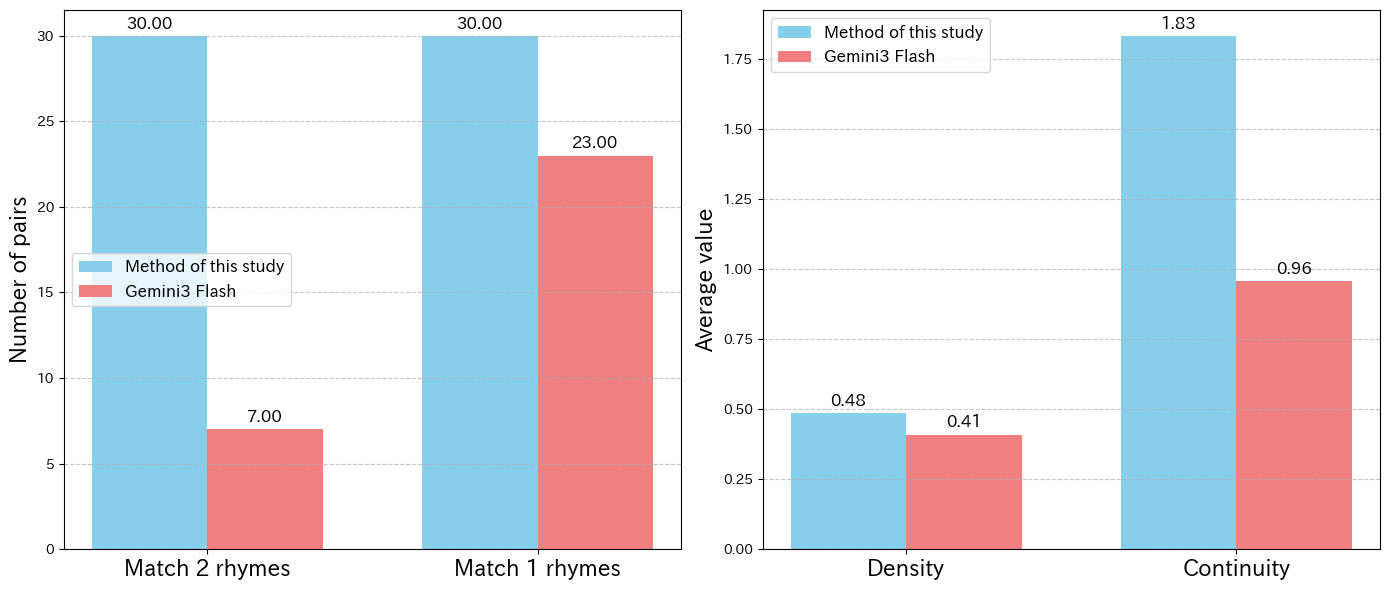

In [ ]:
import MeCab
import re
from pykakasi import kakasi
import itertools
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

# --- 1. Initialize & Helper Functions ---

# Pykakasiを「どんな入力でもローマ字(a)を返す」ように設定
kks = kakasi()
kks.setMode("J", "a") # Kanji -> Roman
kks.setMode("H", "a") # Hiragana -> Roman
kks.setMode("K", "a") # Katakana -> Roman
kks.setMode("r", "Hepburn") # 訓令式(Kunrei)よりヘボン式の方が一般的ですが、母音抽出ならどちらでもOK
conv = kks.getConverter()

# MeCabで読みを取得（失敗したら元の単語を返す）
def get_reading_text(sentence):
    try:
        tagger = MeCab.Tagger()
        node = tagger.parseToNode(sentence)
        readings = []
        while node:
            # 辞書によってフォーマットが違うため、安全に取得
            if node.feature:
                features = node.feature.split(',')
                # 一般的なipadic等はindex 8が読み仮名
                if len(features) > 8 and features[8] != '*':
                    readings.append(features[8])
                elif node.surface:
                    readings.append(node.surface)
            elif node.surface:
                readings.append(node.surface)
            node = node.next
        return ''.join(readings)
    except:
        # MeCabが動かない環境用のフォールバック
        return sentence

# ローマ字と母音列への変換（デバッグ機能付き）
def sentence_to_vowels_verbose(sentence, debug=False):
    if not sentence: return "", ""

    # 1. MeCabで読み（カタカナ等）に変換
    reading = get_reading_text(sentence)

    # 2. Pykakasiでローマ字に変換
    # strip()で余計な空白を除去
    romaji = conv.do(reading).strip().lower()

    # 3. 撥音(n)の処理
    romaji = re.sub(r'n(?![aeiou])', 'nn', romaji)
    romaji = re.sub(r'n$', 'nn', romaji)

    # 4. 母音抽出
    vowel_seq = []
    i = 0
    while i < len(romaji):
        if romaji[i:i+2] == 'nn':
            vowel_seq.append('N')
            i += 2
            while i < len(romaji) and romaji[i:i+2] == 'nn':
                i += 2
        elif romaji[i] in 'aeiou':
            vowel_seq.append(romaji[i])
            i += 1
        else:
            i += 1
    vowels = ''.join(vowel_seq)

    if debug:
        print(f"DEBUG: Input='{sentence}' -> Reading='{reading}' -> Romaji='{romaji}' -> Vowels='{vowels}'")

    return romaji, vowels

# --- 2. Parse LaTeX Tabular Data ---
def parse_latex_tabular(latex_string):
    grid_data = []
    lines = latex_string.strip().split('\n')

    for line in lines:
        line = line.strip()
        # raw string (r) を使ってWarning回避
        if not line or line.startswith(r'\hline') or line == r'\hline':
            continue

        # 行ラベル削除
        line = re.sub(r'^\s*行\d+\s*&', '', line)
        line = re.sub(r'\\\\\s*$', '', line)
        line = re.sub(r'\\$', '', line)

        row_values = [col.strip() for col in line.split('&')]

        if not row_values or all(not val for val in row_values):
            continue

        grid_data.append(row_values)

    return grid_data

# --- 3. Evaluate Rhyme Metrics ---
def evaluate_grid_rhyme_metrics(grid, h_pattern, v_pattern, grid_name="Unnamed Grid"):
    rows = len(grid)
    cols = len(grid[0]) if rows > 0 else 0

    if rows == 0 or cols == 0:
        print(f"Error: {grid_name} - Input grid is empty.")
        return None

    # デバッグ表示：最初の数単語だけ変換テストを行う
    print(f"\n[{grid_name}] Data Parsing Check ({rows}x{cols}):")
    # 最初の行の単語を表示して変換がうまくいっているか確認
    if rows > 0:
        for w in grid[0]:
            if w: sentence_to_vowels_verbose(w, debug=True)

    # 全単語の母音マップ作成
    vowel_map = {}
    for r in range(rows):
        for c in range(cols):
            if c < len(grid[r]):
                word = grid[r][c]
                if word:
                    _, vowels = sentence_to_vowels_verbose(word)
                    vowel_map[(r, c)] = vowels
                else:
                    vowel_map[(r, c)] = ''
            else:
                vowel_map[(r, c)] = ''

    # ターゲットペアの生成
    structure_pairs = set()

    # 横方向
    for r in range(rows):
        if h_pattern == "AABB":
            structure_pairs.add(((r, 0), (r, 1))); structure_pairs.add(((r, 2), (r, 3)))
        elif h_pattern == "ABAB":
            structure_pairs.add(((r, 0), (r, 2))); structure_pairs.add(((r, 1), (r, 3)))
        elif h_pattern == "ABBA":
            structure_pairs.add(((r, 0), (r, 3))); structure_pairs.add(((r, 1), (r, 2)))

    # 縦方向
    for c in range(cols):
        for start_r in range(0, rows, 4):
            if start_r + 3 >= rows: break
            if v_pattern == "AABB":
                structure_pairs.add(((start_r+0, c), (start_r+1, c)))
                structure_pairs.add(((start_r+2, c), (start_r+3, c)))
            elif v_pattern == "ABAB":
                structure_pairs.add(((start_r+0, c), (start_r+2, c)))
                structure_pairs.add(((start_r+1, c), (start_r+3, c)))
            elif v_pattern == "ABBA":
                structure_pairs.add(((start_r+0, c), (start_r+3, c)))
                structure_pairs.add(((start_r+1, c), (start_r+2, c)))

    print(f"[{grid_name}] Target Pairs defined: {len(structure_pairs)}")

    rhyme_stats = {
        "tail_2_vowel_matches": 0,
        "tail_1_vowel_matches": 0,
        "total_rhyme_density": 0.0,
        "total_rhyme_streak": 0,
        "num_evaluated_rhyme_pairs": 0
    }

    for (p1_pos, p2_pos) in structure_pairs:
        if p1_pos[0] >= rows or p1_pos[1] >= cols or p2_pos[0] >= rows or p2_pos[1] >= cols:
            continue

        v1 = vowel_map.get(p1_pos, '')
        v2 = vowel_map.get(p2_pos, '')

        # 母音が取得できていない場合はスキップ
        if not v1 or not v2:
            continue

        rhyme_stats["num_evaluated_rhyme_pairs"] += 1

        if len(v1) >= 2 and len(v2) >= 2 and v1[-2:] == v2[-2:]:
            rhyme_stats["tail_2_vowel_matches"] += 1

        if v1[-1] == v2[-1]:
            rhyme_stats["tail_1_vowel_matches"] += 1

            match_count = sum(a == b for a, b in zip(v1, v2))
            denom = min(len(v1), len(v2))
            density = match_count / denom if denom > 0 else 0
            rhyme_stats["total_rhyme_density"] += density

            max_streak = 0
            streak = 0
            for a, b in zip(v1, v2):
                if a == b:
                    streak += 1
                    max_streak = max(max_streak, streak)
                else:
                    streak = 0
            rhyme_stats["total_rhyme_streak"] += max_streak

    # 平均計算（ゼロ除算回避）
    num_matched = rhyme_stats["tail_1_vowel_matches"]

    if num_matched > 0:
        rhyme_stats["average_rhyme_density"] = rhyme_stats["total_rhyme_density"] / num_matched
        rhyme_stats["average_rhyme_streak"] = rhyme_stats["total_rhyme_streak"] / num_matched
    else:
        rhyme_stats["average_rhyme_density"] = 0.0
        rhyme_stats["average_rhyme_streak"] = 0.0

    return rhyme_stats

# --- 4. Main Execution ---
if __name__ == "__main__":
    TARGET_H_PATTERN = "ABAB"
    TARGET_V_PATTERN = "AABB"

    # LaTeXデータ (raw stringで定義)
    latex_grid1_content = r"""
行1 & 夏空 & 水風船 & 青空 & 流しそうめん & 38 \\
\hline
行2 & 星空 & 高原 & 青い空 & 草原 & 41 \\
\hline
行3 & 涼風 & 七夕 & 木陰 & 砂浜 & 37 \\
\hline
行4 & 夕焼け & クワガタ & 浜辺 & 縁側 & 35 \\
\hline
行5 & 夏祭り & 日傘 & 夏休み & 浴衣 & 47 \\
\hline
行6 & 夕涼み & 天の川 & 水しぶき & シャワー & 35 \\
\hline
行7 & 夏服 & 風浴び & 海風 & ひぐらし & 42 \\
\hline
行8 & 渓流 & 向日葵 & 朝露 & 夕立 & 39 \\
"""

    latex_grid2_content = r"""
row1 & 青空 & 祭り & 夏空 & 花火 & 39\\
\hline
row2 & 星空 & 素足 & 砂浜 & 夏休み & 22\\
\hline
row3 & 入道雲 & 浴衣 & 夏雲 & 日傘 & 35\\
\hline
row4 & 白い雲 & 朝顔 & トンボ & 水鉄砲 & 10\\
\hline
row5 & セミ & 夕焼け & ひぐらし & 日焼け & 25\\
\hline
row6 & 虫取り & 影絵 & 水遊び & 夏景色 & 15\\
\hline
row7 & スイカ & ラムネ & 向日葵 & 海風 & 10\\
\hline
row8 & 浮き輪 & 青葉 & 青い空 & 夜風 & 10\\
"""

    grid1_data = parse_latex_tabular(latex_grid1_content)
    grid2_data = parse_latex_tabular(latex_grid2_content)

    metrics1 = evaluate_grid_rhyme_metrics(grid1_data, TARGET_H_PATTERN, TARGET_V_PATTERN, "Model of this study")
    metrics2 = evaluate_grid_rhyme_metrics(grid2_data, TARGET_H_PATTERN, TARGET_V_PATTERN, "ChatGPT")

    if metrics1 and metrics2:
        print("\n--- Rhyme Evaluation Results ---")

        def print_metrics(m, name):
            print(f"\n{name}:")
            total = m['num_evaluated_rhyme_pairs']
            print(f"  Target Pairs found: {total}")

            if total > 0:
                print(f"  Tail 2 matches: {m['tail_2_vowel_matches']} (Rate: {m['tail_2_vowel_matches']/total:.2%})")
                print(f"  Tail 1 matches: {m['tail_1_vowel_matches']} (Rate: {m['tail_1_vowel_matches']/total:.2%})")
            else:
                print("  Tail 2 matches: 0 (Rate: 0.00%)")
                print("  Tail 1 matches: 0 (Rate: 0.00%)")

            print(f"  Avg Density (matched): {m['average_rhyme_density']:.3f}")
            print(f"  Avg Continuity (matched): {m['average_rhyme_streak']:.3f}")

        print_metrics(metrics1, "Grid 1 (Proposed)")
        print_metrics(metrics2, "Grid 2 (Comparison)")

        # --- 5. Plotting ---
        labels_counts = ['Match 2 rhymes', 'Match 1 rhymes']
        grid1_counts = [metrics1['tail_2_vowel_matches'], metrics1['tail_1_vowel_matches']]
        grid2_counts = [metrics2['tail_2_vowel_matches'], metrics2['tail_1_vowel_matches']]

        labels_ratios = ['Density', 'Continuity']
        grid1_ratios = [metrics1['average_rhyme_density'], metrics1['average_rhyme_streak']]
        grid2_ratios = [metrics2['average_rhyme_density'], metrics2['average_rhyme_streak']]

        width = 0.35
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        ax0 = axes[0]
        x_counts = np.arange(len(labels_counts))
        rects0_1 = ax0.bar(x_counts - width/2, grid1_counts, width, label='Method of this study', color='skyblue')
        rects0_2 = ax0.bar(x_counts + width/2, grid2_counts, width, label='Gemini3 Flash', color='lightcoral')
        ax0.set_ylabel('Number of pairs', fontsize=16)
        ax0.set_xticks(x_counts)
        ax0.set_xticklabels(labels_counts, fontsize=16)
        ax0.legend(fontsize=12)
        ax0.grid(axis='y', linestyle='--', alpha=0.7)

        ax1 = axes[1]
        x_ratios = np.arange(len(labels_ratios))
        rects1_1 = ax1.bar(x_ratios - width/2, grid1_ratios, width, label='Method of this study', color='skyblue')
        rects1_2 = ax1.bar(x_ratios + width/2, grid2_ratios, width, label='Gemini3 Flash', color='lightcoral')
        ax1.set_ylabel('Average value', fontsize=16)
        ax1.set_xticks(x_ratios)
        ax1.set_xticklabels(labels_ratios, fontsize=16)
        ax1.legend(fontsize=12)
        ax1.grid(axis='y', linestyle='--', alpha=0.7)

        def autolabel(rects, ax):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=12)

        autolabel(rects0_1, ax0)
        autolabel(rects0_2, ax0)
        autolabel(rects1_1, ax1)
        autolabel(rects1_2, ax1)

        fig.tight_layout()
        plt.show()